# **Pairs Trading with Equities in the Energy Sector**

**Potential Pairs**:
- EUR/USD
- USD/JPY
- GBP/USD

The above are good starting pairs due to how popular they are, allowing for high liquidity and better trading conditions.

**The following are pairs that have "greater risk" due to their volatility**:
- GBP/JPY (Dubbed the "beast" for it's volatility, so good for quick price movements but would be hard to start off with)
- EUR/GBP (Good for more advanced technical analysis and has predictable ranges)
- AUD/USD or NZD/USD (commodity-linked pairs influenced by global economic conditions, could be very interesting to explore considering the current geopolitical climate)

ExxonMobil (XOM) & Chevron (CVX)
BP plc (BP) & Shell plc (SHEL)
Schlumberger (SLB) & Halliburton (HAL)
ConocoPhillips (COP) & EOG Resources (EOG)
Devon Energy (DVN) & Diamondback Energy (FANG)
Valero Energy (VLO) & Marathon Petroleum (MPC)
Kinder Morgan (KMI) & Williams Companies (WMB)

### **What is Pairs Trading?** 

Pairs trading is a trading strategy that uses two cointegrated securities and trades them as a pair--shorting one security, while longing the other. The entire premise is to profit off of the continuous spread between the two securities, but in order to do that the spread must be stationary throughout time--a feature of successful cointegrated pairs.

In [9]:
import yfinance as yf
import numpy as np 
import pandas as pd 
import statsmodels
import statsmodels.api as sm 
from statsmodels.tsa.stattools import coint
import seaborn as sns

In [10]:
# downloading different stocks
tickers = ["XOM", "CVX", "BP", "SHEL", "SLB", "HAL", 
    "COP", "EOG", "DVN", "FANG", "VLO", "MPC", "KMI", "WMB"]
stocks_data = yf.download(tickers, start = '2013-01-01', )
#start testing from 2019, train: on 2019-2022, validate: 2023/2024, test: 2025/26

[*********************100%***********************]  14 of 14 completed


In [11]:
stocks_data.head()

Price           Close                                                         \
Ticker             BP        COP        CVX        DVN        EOG       FANG   
Date                                                                           
2013-01-02  19.834007  38.004330  63.732265  34.511578  44.331676  14.789641   
2013-01-03  20.231443  37.978645  63.460884  35.123405  44.510880  14.712777   
2013-01-04  20.413799  38.402267  63.795765  35.906258  45.091545  15.412286   
2013-01-07  20.292233  37.978645  63.362759  35.919407  45.159657  15.965737   
2013-01-08  20.292233  37.465172  63.079865  35.662857  44.496540  15.835065   

Price                                                   ...   Volume          \
Ticker            HAL        KMI        MPC       SHEL  ...      EOG    FANG   
Date                                                    ...                    
2013-01-02  28.119432  18.948397  21.829517  35.299931  ...  3665200  189700   
2013-01-03  28.591898  19.181814  21.219078  35.182640  ...  2928400   89100   
2013-01-04  28.859629  19.041758  21.331617  35.376411  ...  2518600  173300   
2013-01-07  28.859629  19.358173  20.547243  35.177544  ...  2857800  210300   
2013-01-08  28.497406  19.368546  20.990591  35.101048  ...  3122400  229400   

Price                                                                         \
Ticker           HAL      KMI       MPC     SHEL      SLB       VLO      WMB   
Date                                                                           
2013-01-02  10230700  5596300   6321400  2999814  6391400  10071145  9398100   
2013-01-03  16641200  5574900   7296400  1845684  6063000   9637593  7694000   
2013-01-04   8152700  5350100   6589200  1939538  5165300  11940354  6857900   
2013-01-07   7676400  5109800  11086800  2014269  4104500  12946287  4013500   
2013-01-08  12052900  3633100   9818800  2265710  5274500  14459726  7692700   

Price                 
Ticker           XOM  
Date                  
2013-01-02  16143700  
2013-01-03  13268200  
2013-01-04  11427900  
2013-01-07  11799800  
2013-01-08  14226400  

[5 rows x 70 columns]

In [12]:
# we want to get rid of the other columns, we only care about closing price
close_col = stocks_data.columns[:14]
stocks_data = stocks_data.loc[:, close_col]
stocks_data.columns = stocks_data.columns.droplevel(0)

We are going to use closing prices to test cointegration, as many academic journals and other examples of pairs trading strategies use close prices.

In [16]:
def find_cointegrated_pairs(stocks_data):
    n = len(tickers) #number of stocks working with
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            Stock1 = stocks_data[tickers[i]]
            print(Stock1)
            Stock2 = stocks_data[tickers[j]]
            result = coint(Stock1, Stock2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((tickers[i], tickers[j]))
    return score_matrix, pvalue_matrix, pairs

In [17]:
scores, pvalues, pairs = find_cointegrated_pairs(stocks_data)

Date
2013-01-02     52.043392
2013-01-03     51.949512
2013-01-04     52.190022
2013-01-07     51.585781
2013-01-08     51.908424
                 ...    
2026-03-26    165.429993
2026-03-27    170.990005
2026-03-30    171.470001
2026-03-31    169.660004
2026-04-01    160.779999
Name: XOM, Length: 3332, dtype: float64
Date
2013-01-02     52.043392
2013-01-03     51.949512
2013-01-04     52.190022
2013-01-07     51.585781
2013-01-08     51.908424
                 ...    
2026-03-26    165.429993
2026-03-27    170.990005
2026-03-30    171.470001
2026-03-31    169.660004
2026-04-01    160.779999
Name: XOM, Length: 3332, dtype: float64
Date
2013-01-02     52.043392
2013-01-03     51.949512
2013-01-04     52.190022
2013-01-07     51.585781
2013-01-08     51.908424
                 ...    
2026-03-26    165.429993
2026-03-27    170.990005
2026-03-30    171.470001
2026-03-31    169.660004
2026-04-01    160.779999
Name: XOM, Length: 3332, dtype: float64
Date
2013-01-02     52.043392
2013-01-03

[('BP', 'SHEL')]


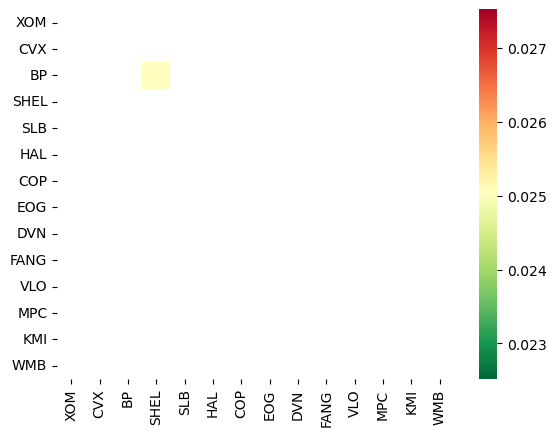

In [18]:

sns.heatmap(pvalues, xticklabels=tickers, yticklabels=tickers, cmap='RdYlGn_r' 
                , mask = (pvalues >= 0.05)
                )
print(pairs)


After running some analysis, we see that out of the 91 possible combinations from the 14 stocks, we see that (BP, SHEL) are the only two that appear cointegrated. With a significance level of 0.025, we can continue testing on this pair to see if it works in a trading setting. 